In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from tqdm import tqdm
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler

from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from umap import UMAP

import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rc('font',family = 'Arial')

### **Чтение файла с данными**

In [2]:
df = pd.read_csv('german_credit_data.csv')
columns = list(df.columns)[1:]
df = df[columns]
df_ = df.copy()
df.head(7)

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
0,67,male,2,own,NaN,little,1169,6,radio/TV
1,22,female,2,own,little,moderate,5951,48,radio/TV
2,49,male,1,own,little,NaN,2096,12,education
3,45,male,2,free,little,little,7882,42,furniture/equipment
4,53,male,2,free,little,little,4870,24,car
5,35,male,1,free,NaN,NaN,9055,36,education
6,53,male,2,own,quite rich,NaN,2835,24,furniture/equipment


In [3]:
# Числовые признаки
numerical = ['Age', 'Credit amount', 'Duration']

# Категориальные признаки
categorical = ['Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account', 'Purpose']

### EDA (Exploratory Data Analysis)

### *В Датасете представлены следующие колонки:*

- **Age** - Возраст
- **Sex** - Пол
- **Job** - 0 - неквалифицированный и нерезидент, 1 - неквалифицированный и постоянный, 2 - квалифицированный, 3 - высококвалифицированный специалист
- **Housing** - собственное, арендуемое или бесплатное
- **Saving accounts** (Сберегательные счета) - небольшие, умеренные, довольно богатые, разбогатевшие
- **Checking account** (Текущий счёт) - числовой, в немецких марках
- **Credit amount** (Сумма кредита) - числовой, в немецких марках
- **Duration** (Срок действия) - числовой, в месяцах
- **Purpose** (Цель использования) - автомобиль, мебель/оборудование, радио/телевизор, бытовая техника, ремонт, образование, бизнес, отдых/другое

In [4]:
df.describe()

,Age,Job,Credit amount,Duration
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,35.546000,1.904000,3271.258000,20.903000
std,11.375469,0.653614,2822.736876,12.058814
min,19.000000,0.000000,250.000000,4.000000
25%,27.000000,2.000000,1365.500000,12.000000
50%,33.000000,2.000000,2319.500000,18.000000
75%,42.000000,2.000000,3972.250000,24.000000
max,75.000000,3.000000,18424.000000,72.000000


### Пропуски

In [5]:
df.isnull().sum()

Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount         0
Duration              0
Purpose               0
dtype: int64

#### *Преобразуем признаки Sex, Housing, Saving accounts, Checking account, Purpose в числовые с помощью LabelEncoder*. А к числовым признакам применим MinMaxScaler

In [6]:
le = LabelEncoder()

#columns_need_replace = ['Sex', 'Housing', 'Saving accounts', 'Checking account', 'Purpose']
for col in categorical:
    #le = LabelEncoder()
    le.fit(df[col])
    df[col] = le.transform(df[col])

# Min-Max Scaling
min_max_scaler = MinMaxScaler()
df_scaled = df.copy()
X_scaled = min_max_scaler.fit_transform(df[numerical])
df_scaled[numerical] = pd.DataFrame(X_scaled, columns = df[numerical].columns)

In [7]:
df_scaled.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
0,0.857143,1,2,1,4,0,0.050567,0.029412,5
1,0.053571,0,2,1,0,1,0.313690,0.647059,5
2,0.535714,1,1,1,0,3,0.101574,0.117647,3
3,0.464286,1,2,0,0,0,0.419941,0.558824,4
4,0.607143,1,2,0,0,0,0.254209,0.294118,1


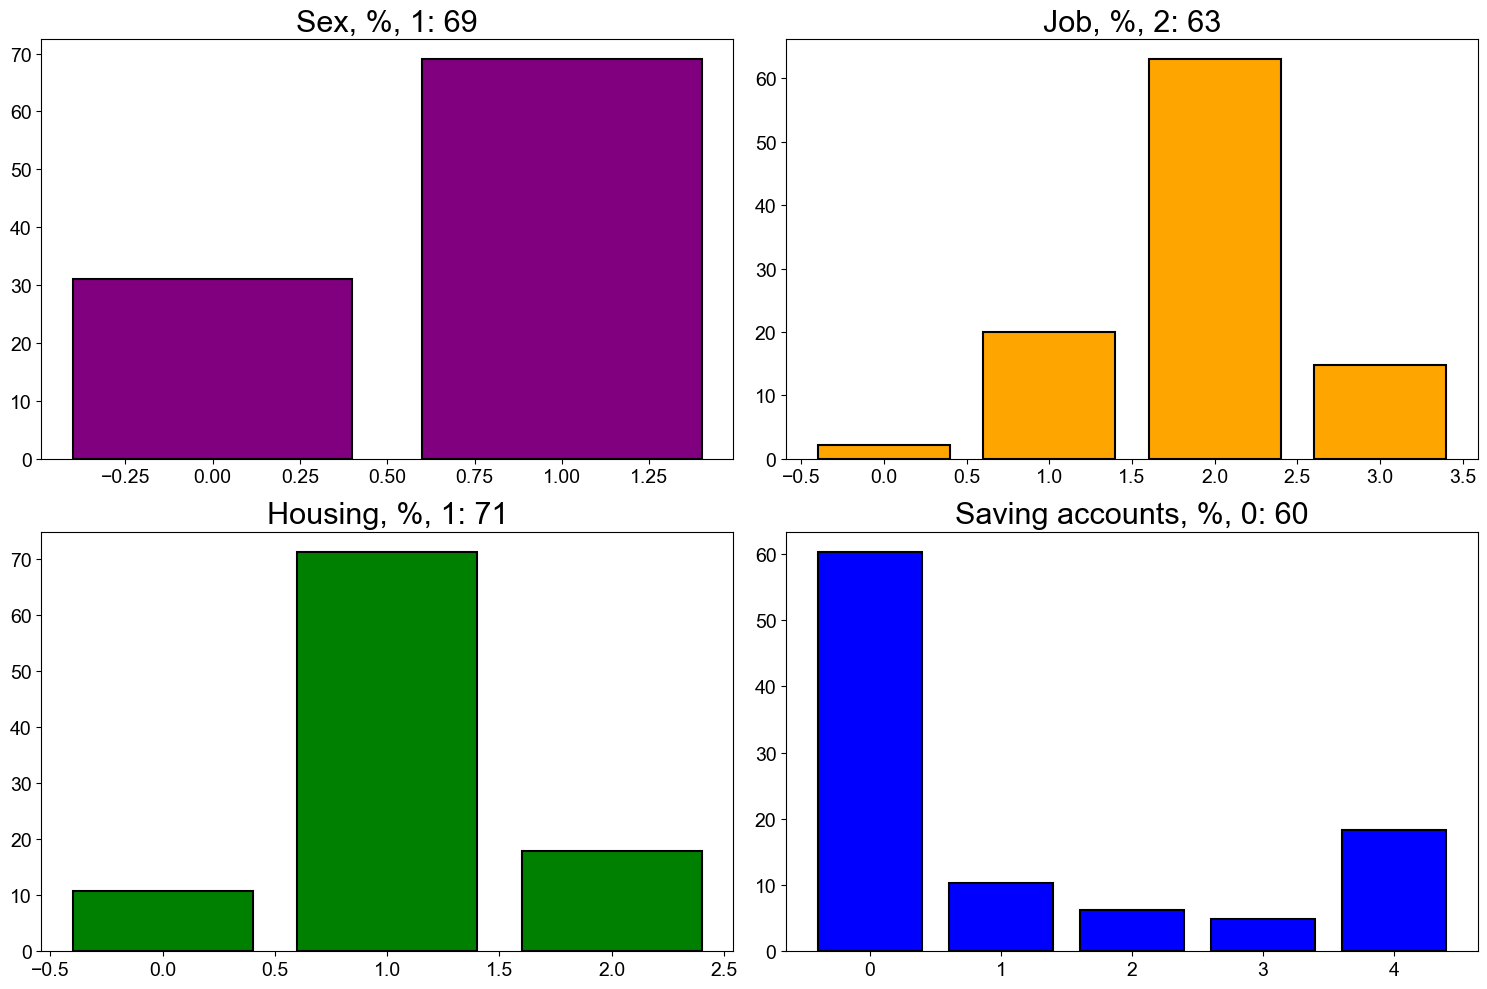

In [8]:
cols_group_1 = df_.columns[1:5]
cols_group_2 = df_.columns[5:]
colors = [
    'purple', 'orange', 'green', 'blue', 'tomato', 'yellowgreen', 'mediumorchid',
    'magenta', 'navy', 'crimson', 'darkgreen', 'dodgerblue'
]

fig, axs = plt.subplots(2, len(cols_group_1) // 2, figsize = (15, 10))
axs = axs.flatten()

for i, col in enumerate(cols_group_1):
    target = df[col].value_counts(normalize=True) * 100
    #axs[i].figure(figsize = (7.9, 5.2))
    axs[i].tick_params(axis='both', which='major', labelsize=14)
    axs[i].set_title(f'{col}, %, {(list(target.index))[0]}: {round(max(list(target)))}', fontsize = 22, color = 'black')
    axs[i].bar(list(target.index), target, color=colors[i], linewidth=1.5, edgecolor='k')
plt.tight_layout()
plt.show()

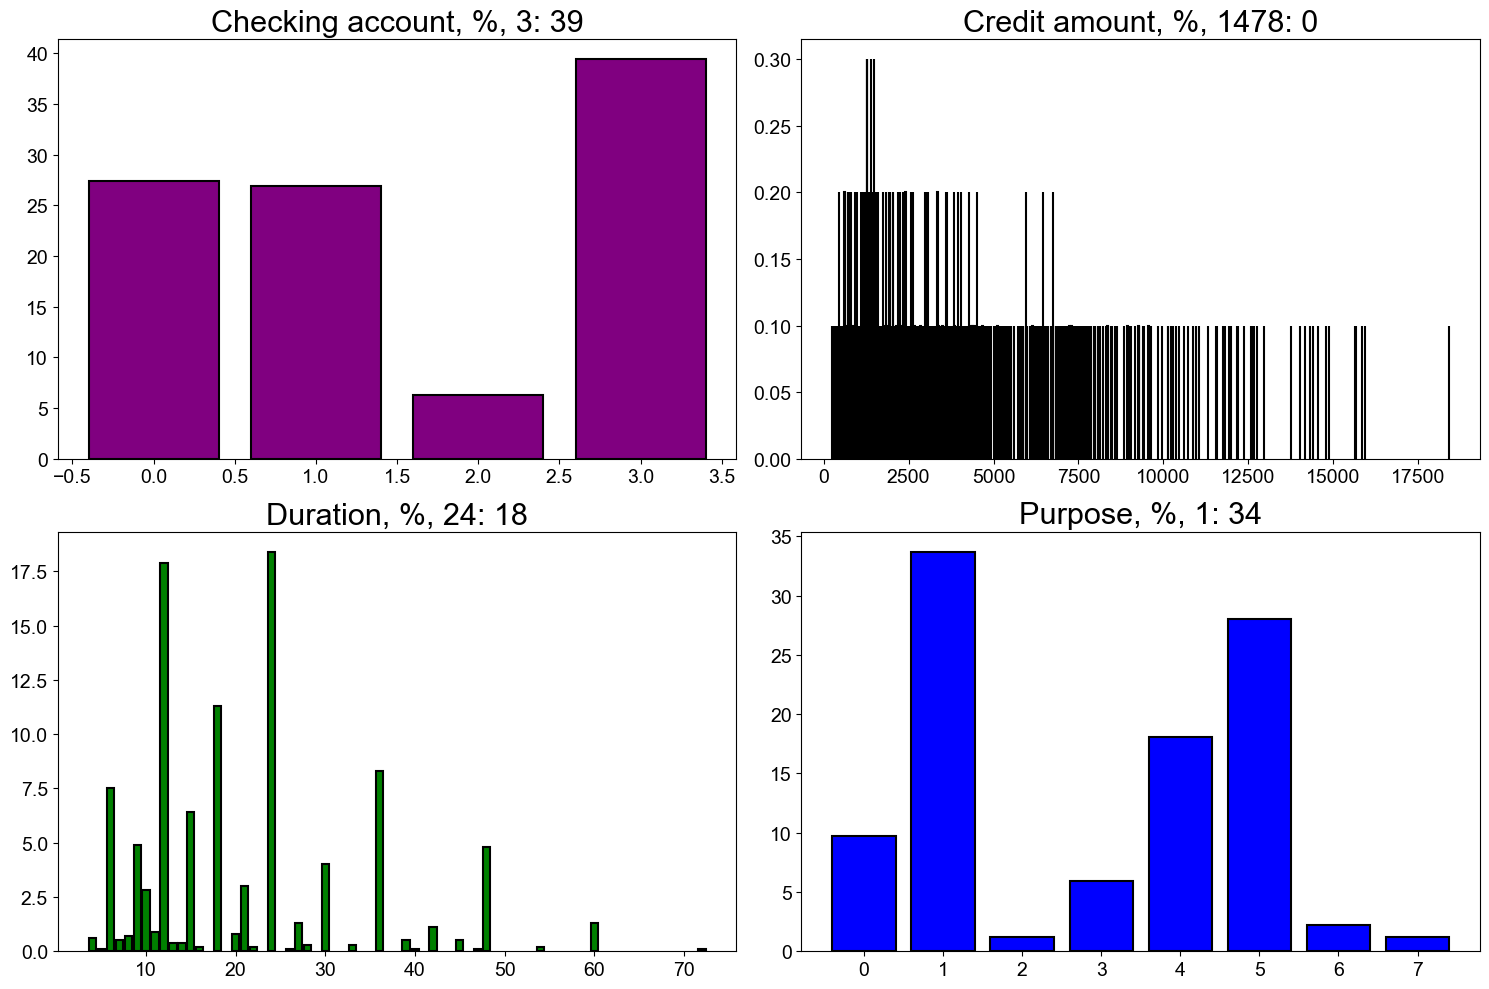

In [9]:
fig, axs = plt.subplots(2, len(cols_group_1) // 2, figsize = (15, 10))
axs = axs.flatten()

for i, col in enumerate(cols_group_2):
    target = df[col].value_counts(normalize = True) * 100
    #axs[i].figure(figsize = (7.9, 5.2))
    axs[i].tick_params(axis='both', which='major', labelsize=14)
    axs[i].set_title(f'{col}, %, {(list(target.index))[0]}: {round(max(list(target)))}', fontsize = 22, color = 'black')
    axs[i].bar(list(target.index), target, color=colors[i], linewidth=1.5, edgecolor='k')
plt.tight_layout()
plt.show()

### Матрица коррелляции

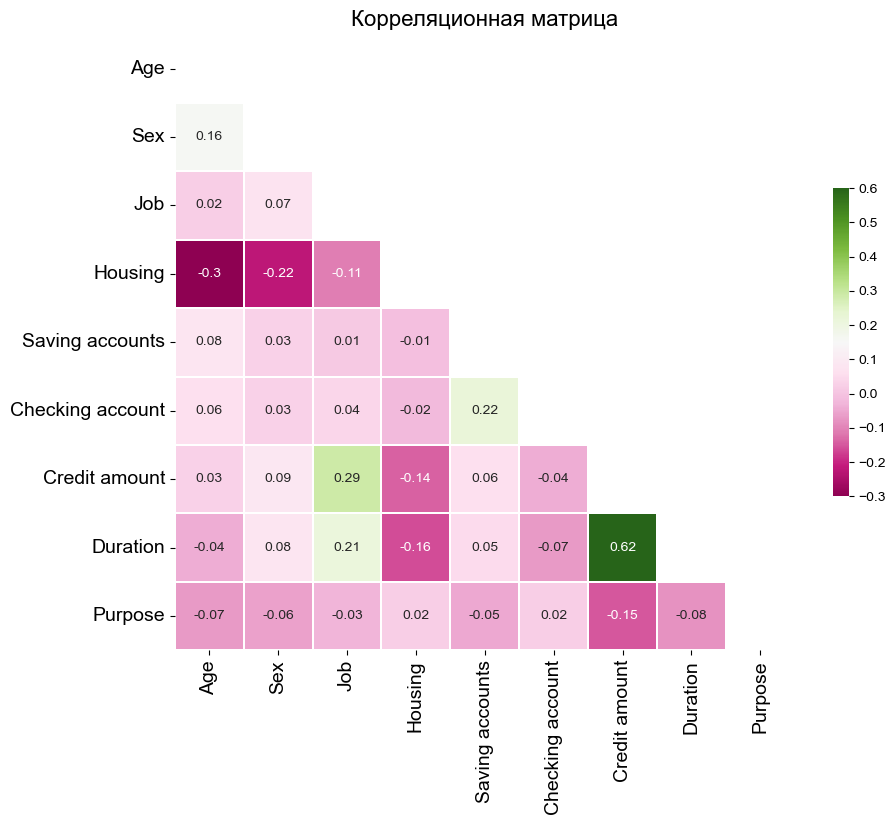

In [10]:
corrM = df.corr()
#Сделаем тепловую карту треугольной
matrix = np.triu(df.corr())

plt.figure(figsize=(10, 8), dpi=100)
plt.tick_params(axis='both', which='major', labelsize=14)
sns.heatmap(
    corrM.round(2),
    annot=True,
    vmin=-0.3,
    vmax=0.6,
    center=0.15,
    cmap='PiYG',
    cbar_kws={'shrink': .5},
    annot_kws={'size': 10}, # размер шрифта в ячейке
    linewidth=0.3,
    mask=matrix
)
plt.yticks(fontsize=14)
#plt.xticks(rotation=30, fontsize=12)

plt.title('Корреляционная матрица', fontsize=16)
plt.show()

### Построим BoxPlot (Диаграммы размаха)

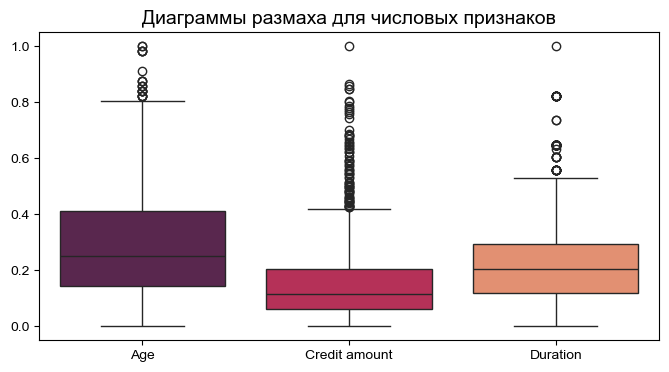

In [11]:
plt.figure(figsize=(8, 4), dpi=100)
plt.tick_params(axis='both', which='major', labelsize=10)
sns.boxplot(data=df_scaled[numerical], palette='rocket')
plt.title('Диаграммы размаха для числовых признаков', fontsize=14)
plt.show()

### Снижение Размерности для Визуализации

In [12]:
umap = UMAP(n_components=2, random_state=101)
X_umap = umap.fit_transform(X_scaled)
print(X_scaled.shape, X_umap.shape)

(1000, 3) (1000, 2)


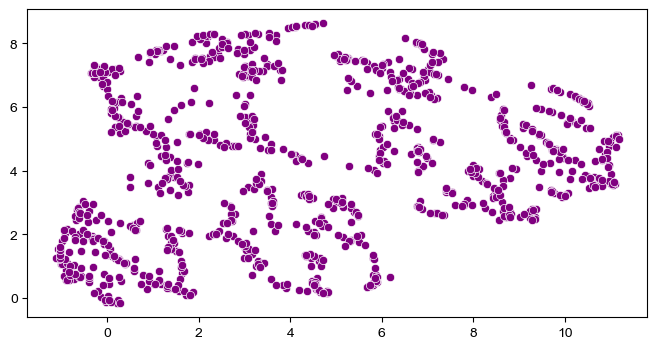

In [13]:
plt.figure(figsize=(8, 4))
plt.tick_params(axis='both', which='major', labelsize=10)
sns.scatterplot(x=X_umap[:, 0], y=X_umap[:, 1], color='purple')
plt.show()

## КЛАСТЕРИЗАЦИЯ

### Алгоритм KMEANS

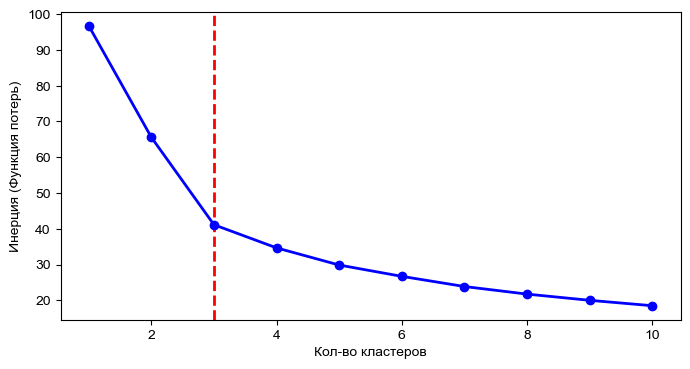

In [14]:
inertia = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=101, n_init=10).fit(X_scaled)
    labels = kmeans.labels_
    inertia_i = kmeans.inertia_
    inertia.append(inertia_i)

plt.figure(figsize=(8, 4), dpi=100)
plt.tick_params(axis='both', which='major', labelsize=10)
plt.axvline(x=3.0, linewidth=2, color='red', linestyle='dashed')
plt.xlabel('Кол-во кластеров', fontsize=10, color='black')
plt.ylabel('Инерция (Функция потерь)', fontsize=10, color='black')
plt.plot(range(1, 11), inertia, marker='o', color='blue', linewidth=2)
plt.show()

### Вывод: Оптимальное число кластеров равно 3

#### Построение модели для 3 кластеров

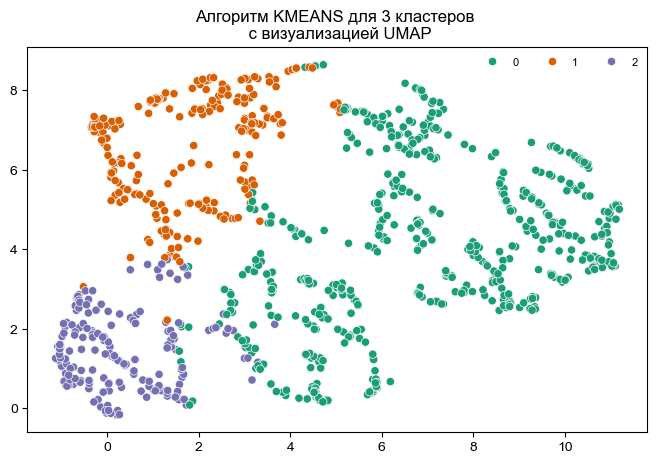

In [15]:
# Оптимальное количество кластеров
optimal_k = 3

kmeans = KMeans(n_clusters=optimal_k, random_state=101, n_init=10).fit(X_scaled)
labels = kmeans.labels_

# Визуализация
plt.figure(figsize=(8, 5), dpi=100)
plt.tick_params(axis='both', which='major', labelsize=10)
sns.scatterplot(
    x=X_umap[:, 0],
    y=X_umap[:, 1],
    hue=labels,
    palette='Dark2'
)
plt.legend(fontsize=8, loc ='best', ncols=3, frameon=False)
plt.title(f'Алгоритм KMEANS для {optimal_k} кластеров \n c визуализацией UMAP', fontsize=12)
plt.show()

### Визуализация с помощью tSNE на двумерной плоскости

In [16]:
# Применение t-SNE с разной перплексией
tsne_low_perplexity = TSNE(n_components=2, perplexity=5)
reduced_data_low_perplexity = tsne_low_perplexity.fit_transform(X_scaled)

tsne_high_perplexity = TSNE(n_components=2, perplexity=50)
reduced_data_high_perplexity = tsne_high_perplexity.fit_transform(X_scaled)

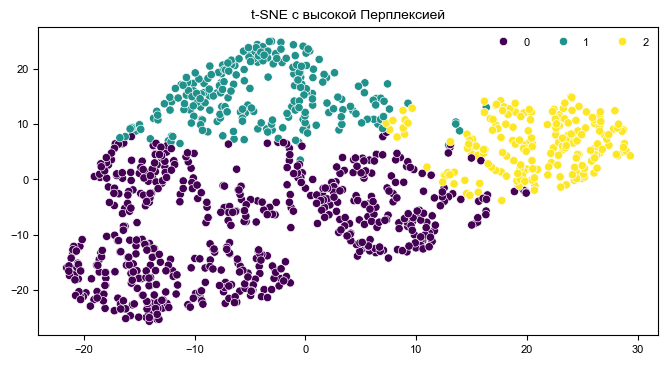

In [17]:
# Визуализация
plt.figure(figsize=(8, 4), dpi=100)
plt.tick_params(axis='both', which='major', labelsize=8)
sns.scatterplot(
    x=reduced_data_high_perplexity[:, 0],
    y=reduced_data_high_perplexity[:, 1],
    hue = labels,
    palette = 'viridis'
)
plt.legend(fontsize=8, loc='best', ncols=3, frameon=False)
plt.title(f't-SNE с высокой Перплексией', fontsize=10)
plt.show()

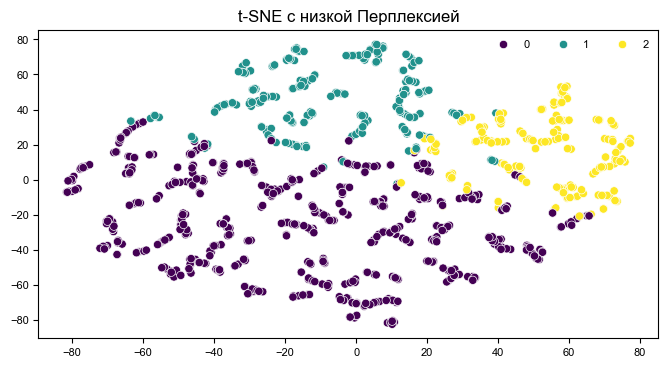

In [18]:
# Визуализация
plt.figure(figsize=(8, 4), dpi=100)
plt.tick_params(axis='both', which='major', labelsize=8)
sns.scatterplot(
    x=reduced_data_low_perplexity[:, 0],
    y=reduced_data_low_perplexity[:, 1],
    hue=labels,
    palette='viridis'
)
plt.legend(fontsize=8, loc='best', ncols=3, frameon=False)
plt.title(f't-SNE с низкой Перплексией', fontsize=12)
plt.show()

### **Вывод:** Один из ключевых параметров tSNE – это перплексия (perplexity). Она определяет, сколько соседей учитываются в расчете условных вероятностей сходства. Большая перплексия приводит к усреднению вероятностей и созданию более глобальной структуры, в то время как маленькая перплексия подчеркивает локальную структуру. Для настоящей задачи наиболее удачным оказывается параметр perplexity = 50.

## Агломеративная кластеризация

### Построим Дендрограмму

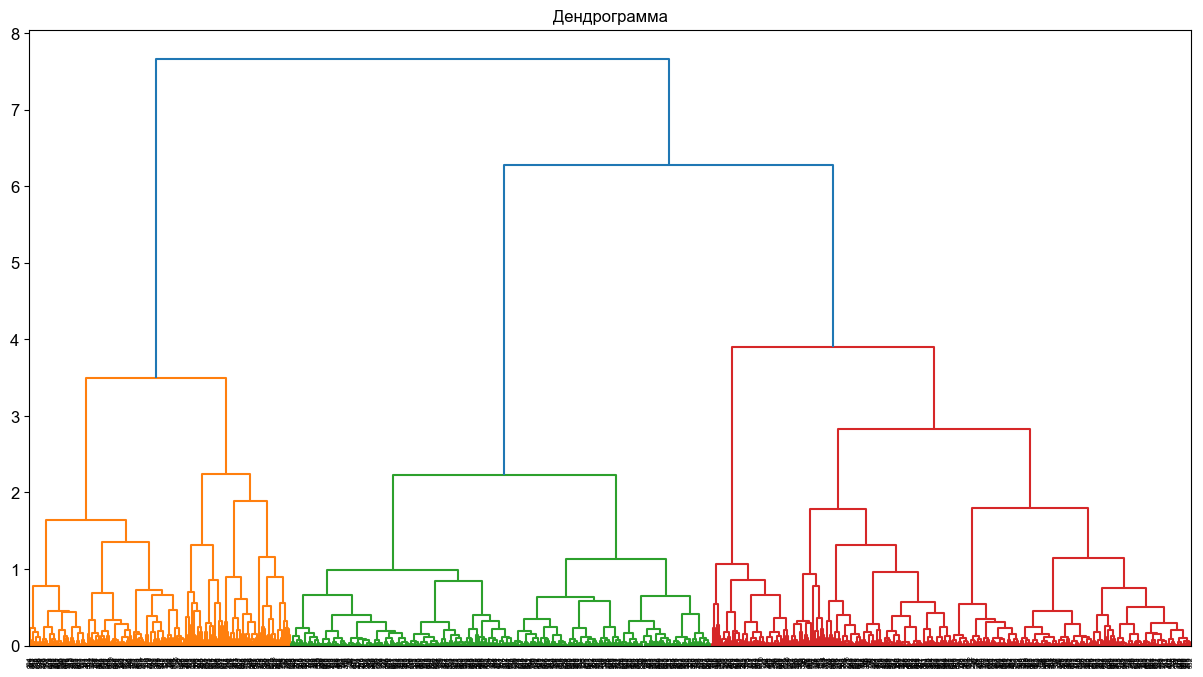

In [19]:
plt.figure(figsize=(15, 8), dpi=100)
plt.tick_params(axis='both', which='major', labelsize=12)
linkage_ = linkage(X_scaled, method='ward')
dendrogram_ = dendrogram(linkage_)
plt.title('Дендрограмма', fontsize=12)
plt.show()

### Силуэтный коэффициент (Silhouette plot)

100%|████████████████████████████████████████████████████████████████████████████████████| 9/9 [00:00<00:00, 27.85it/s]


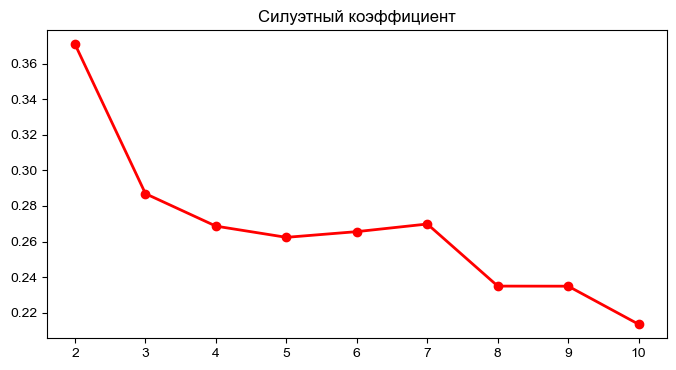

In [20]:
silhouette = []
for i in tqdm(range(2, 11)):
    agg = AgglomerativeClustering(n_clusters=i).fit(X_scaled)
    labels = agg.labels_
    score = silhouette_score(X_scaled, labels)
    silhouette.append(score)

plt.figure(figsize=(8, 4), dpi=100)
plt.tick_params(axis='both', which='major', labelsize=10)
plt.plot(range(2, 11), silhouette, marker='o', color='red', linewidth=2)
plt.title('Силуэтный коэффициент', fontsize=12)
plt.show()

#### Вывод: максимальное значение (наиболее близкое к 1) наблюдается при числе кластеров равном 2. Визуально мы это также видим.

### Процесс кластеризации

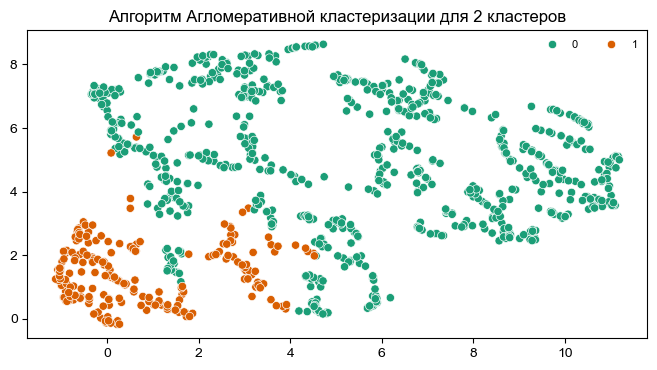

In [21]:
optimal_k = 2

agg = AgglomerativeClustering(n_clusters=optimal_k).fit(X_scaled)
labels = agg.labels_

# Визуализация
plt.figure(figsize=(8, 4), dpi=100)
plt.tick_params(axis='both', which='major', labelsize=10)
sns.scatterplot(
    x=X_umap[:, 0],
    y=X_umap[:, 1],
    hue=labels,
    palette='Dark2'
)
plt.legend(fontsize=8, loc='best', ncols=2, frameon=False)
plt.title(f'Алгоритм Агломеративной кластеризации для {optimal_k} кластеров', fontsize=12)
plt.show()

## DBSCAN

In [22]:
def dbscan_clustering(eps_range, X):
    eps_range = eps_range
    silhouette = []
    clusters = []
    for i in tqdm(eps_range):
        dbscan = DBSCAN(eps=i).fit(X)
        labels = dbscan.labels_
        uniq_labels = np.unique(labels)
        n_clusters = len(uniq_labels[uniq_labels != -1])
        if n_clusters > 1:
            score = silhouette_score(X, labels)
        else:
            score = 0
        silhouette.append(score)
        clusters.append(n_clusters)

    plt.figure(figsize=(5, 5), dpi=100);
    fig, ax1 = plt.subplots()
    
    color = 'tab:red'
    ax1.plot(eps_range, silhouette, marker='o', color=color)
    ax1.set_xlabel('eps')
    ax1.set_ylabel('silhouette', color=color)
    ax1.tick_params(axis='y', labelcolor=color)

    ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis

    color = 'tab:blue'
    ax2.plot(eps_range, clusters, marker='o', color=color)
    ax2.set_ylabel('n_clusters', color=color)
    ax2.tick_params(axis='y', labelcolor=color)

    fig.tight_layout()
    plt.show();

### Изобразим на одном графике Eps и силуэтный коэффициент

100%|██████████████████████████████████████████████████████████████████████████████████| 35/35 [00:00<00:00, 46.20it/s]


<Figure size 500x500 with 0 Axes>

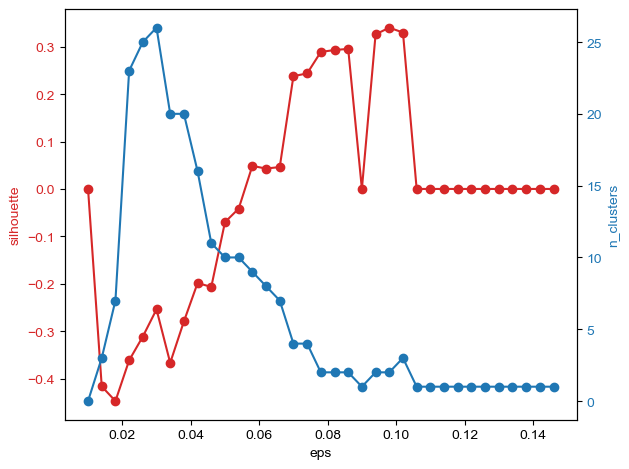

In [23]:
eps_range = np.arange(0.01, 0.15, 0.004)
dbscan_clustering(eps_range, X_scaled);

100%|██████████████████████████████████████████████████████████████████████████████████| 30/30 [00:00<00:00, 40.04it/s]


<Figure size 500x500 with 0 Axes>

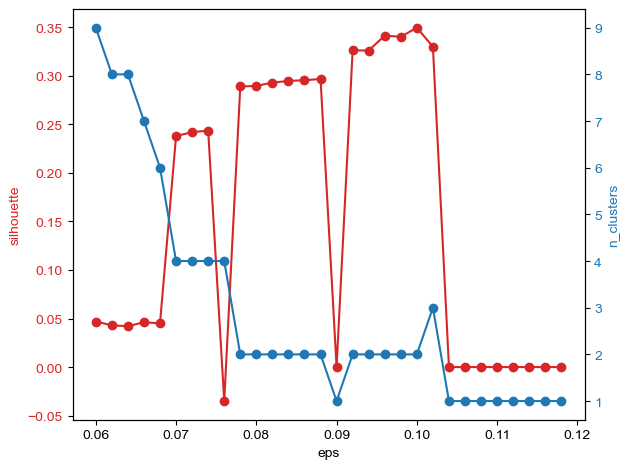

In [24]:
eps_range = np.arange(0.06, 0.12, 0.002)
dbscan_clustering(eps_range, X_scaled)

### Вывод: При eps > 0.1 силуэтный коэффициент обращается в ноль. Поэтому будем рассматривать участок до 0.1
Параметр eps стабилизируется при n_clusters = 2. Таким образом, можно брать диапазон (0.07; 0.1).

100%|██████████████████████████████████████████████████████████████████████████████████| 41/41 [00:01<00:00, 36.69it/s]


<Figure size 500x500 with 0 Axes>

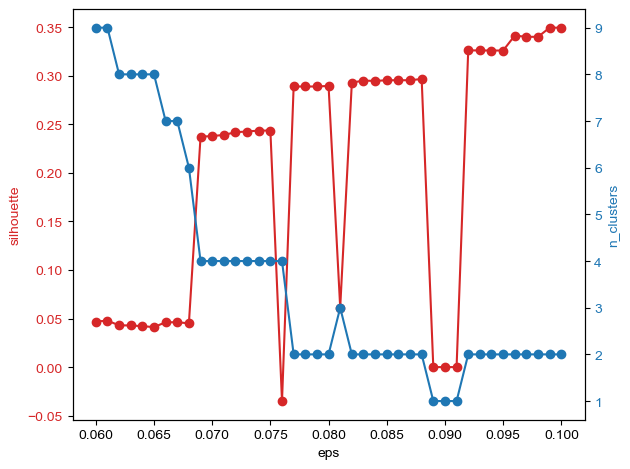

In [25]:
eps_range = np.arange(0.06, 0.1, 0.001)
dbscan_clustering(eps_range, X_scaled);

100%|████████████████████████████████████████████████████████████████████████████████████| 9/9 [00:00<00:00, 33.06it/s]


<Figure size 500x500 with 0 Axes>

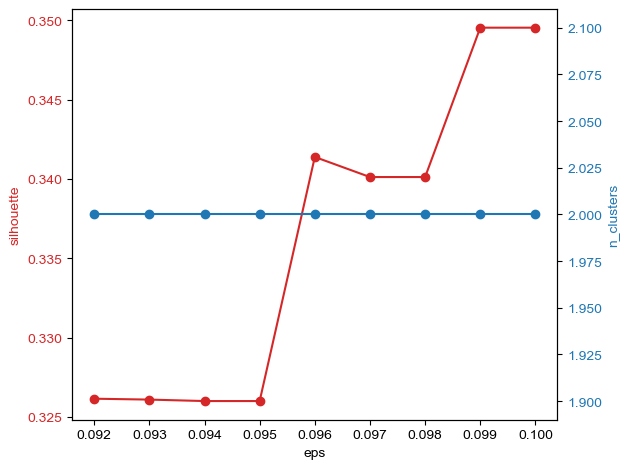

In [26]:
eps_range = np.arange(0.092, 0.1, 0.001)
dbscan_clustering(eps_range, X_scaled);

## Вычисление eps с помощью NearestNeighbors

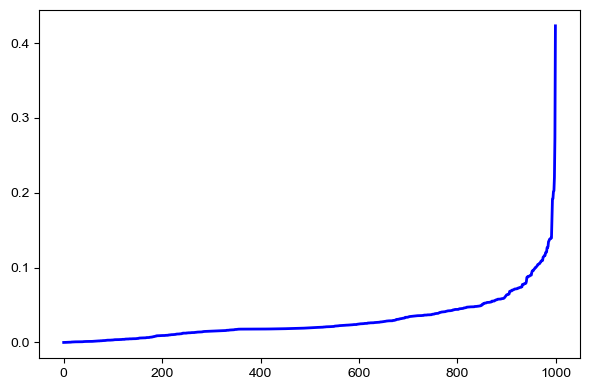

In [27]:
neighbors = NearestNeighbors(n_neighbors=5)
nbors = neighbors.fit(X_scaled)
distance, indices = nbors.kneighbors(X_scaled)

distance = np.sort(distance, axis=0)
distance = distance[:, 1]

plt.figure(figsize=(6, 4), dpi=100)
plt.tick_params(axis='both', which='major', labelsize=10)
plt.plot(distance, color='blue', linewidth=2)
#plt.ylim(0.0, 0.15)
#plt.xlim(800, 900)
plt.tight_layout()
plt.show()

### Кластеризация

кластеров: 2


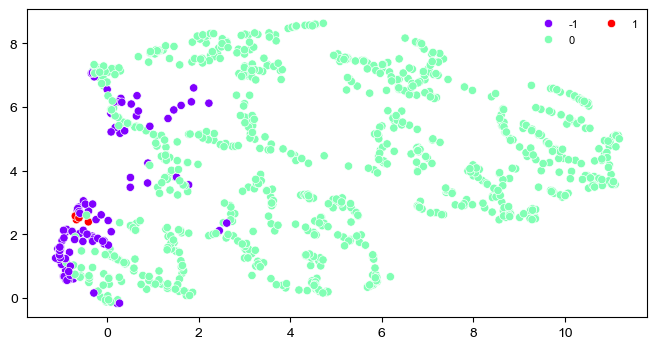

In [28]:
dbscan = DBSCAN(eps=0.095, min_samples=5).fit(X_scaled)
labels = dbscan.labels_
uniq_labels = np.unique(labels)
n_clusters = len(uniq_labels[uniq_labels != -1])
print(f'кластеров: {n_clusters}')

plt.figure(figsize=(8, 4), dpi=100)
plt.tick_params(axis='both', which='major', labelsize=10)
sns.scatterplot(
    x=X_umap[:, 0],
    y=X_umap[:, 1],
    hue=labels,
    palette='rainbow'
)
plt.legend(fontsize=8, loc='best', ncols=n_clusters, frameon=False)
plt.show()

In [29]:
df_scaled['labels'] = labels
df_scaled['labels'].value_counts(normalize = True)

labels
 0    0.901
-1    0.095
 1    0.004
Name: proportion, dtype: float64

#### **Вывод:** По всей видимости DBSCAN показывает себя не с лучшей стороны для данной задачи, поскольку кластеры разной плотности. Лучше с данной задачей справляются другие алгоритмы кластеризации. Лучше всего себя проявляет алгоритм KMEANS, с помощью которого удалось выделить 3 различных кластера.